# Домашнее задание №1
## Часть2: Классификация FashionMNIST
##### Автор: [Радослав Нейчев](https://www.linkedin.com/in/radoslav-neychev/), https://t.me/s/rads_ai

В данном задании вам предстоит решить достаточно простую задачу классификации изображений с помощью сверточных нейронных сетей.

In [26]:
np.random.seed(42)

In [2]:
# do not change the code in the block below
# __________start of block__________
import json
import os
import re

import numpy as np
import torch
import torchvision
from IPython.display import clear_output
from matplotlib import pyplot as plt
from torch import nn
from torch.nn import functional as F
from torchvision.datasets import FashionMNIST

# __________end of block__________

In [3]:
# do not change the code in the block below
# __________start of block__________
def get_predictions(model, eval_data, step=10):

    predicted_labels = []
    model.eval()
    with torch.no_grad():
        for idx in range(0, len(eval_data), step):
            y_predicted = model(eval_data[idx : idx + step].to(device))
            predicted_labels.append(y_predicted.argmax(dim=1).cpu())

    predicted_labels = torch.cat(predicted_labels)
    predicted_labels = ",".join([str(x.item()) for x in list(predicted_labels)])
    return predicted_labels


def get_accuracy(model, data_loader):
    predicted_labels = []
    real_labels = []
    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            y_predicted = model(batch[0].to(device))
            predicted_labels.append(y_predicted.argmax(dim=1).cpu())
            real_labels.append(batch[1])

    predicted_labels = torch.cat(predicted_labels)
    real_labels = torch.cat(real_labels)
    accuracy_score = (predicted_labels == real_labels).type(torch.FloatTensor).mean()
    return accuracy_score


# __________end of block__________

Загрузите файл `hw_overfitting_data_dict.npy` (ссылка есть на странице с заданием), он понадобится для генерации посылок. Код ниже может его загрузить (но в случае возникновения ошибки скачайте и загрузите его вручную).


In [4]:
!wget https://github.com/girafe-ai/ml-course/raw/24f_ysda/homeworks/hw_overfitting/hw_overfitting_data_dict -O hw_overfitting_data_dict.npy

--2025-09-14 12:05:02--  https://github.com/girafe-ai/ml-course/raw/24f_ysda/homeworks/hw_overfitting/hw_overfitting_data_dict
Resolving github.com (github.com)... 140.82.116.4
Connecting to github.com (github.com)|140.82.116.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/girafe-ai/ml-course/24f_ysda/homeworks/hw_overfitting/hw_overfitting_data_dict [following]
--2025-09-14 12:05:02--  https://raw.githubusercontent.com/girafe-ai/ml-course/24f_ysda/homeworks/hw_overfitting/hw_overfitting_data_dict
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6272446 (6.0M) [application/octet-stream]
Saving to: ‘hw_overfitting_data_dict.npy’

hw_overfitting_data 100%[===================>]   5.98M  --.-KB/s 

In [5]:
# do not change the code in the block below
# __________start of block__________
assert os.path.exists(
    "hw_overfitting_data_dict.npy"
), "Please, download `hw_overfitting_data_dict.npy` and place it in the working directory"

# __________end of block__________

Вернемся к задаче распознавания простых изображений, рассмотренной ранее. Но теперь будем работать с набором данных [FashionMNIST](https://github.com/zalandoresearch/fashion-mnist). В данном задании воспользуемся всем датасетом целиком.

__Ваша первая задача: реализовать весь пайплан обучения модели и добиться качества $\geq 88.5\%$ на тестовой выборке.__

Код для обучения модели в данном задании отсутствует. Присутствует лишь несколько тестов, которые помогут вам отладить свое решение. За примером можно обратиться к ноутбукам с предыдущих занятий.

In [6]:
CUDA_DEVICE_ID = 0  # change if needed

In [7]:
# do not change the code in the block below
# __________start of block__________
device = (
    torch.device(f"cuda:{CUDA_DEVICE_ID}") if torch.cuda.is_available() else torch.device("cpu")
)
# __________end of block__________

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.89MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.1MB/s]


Text(0.5, 1.0, 'Image label: 8')

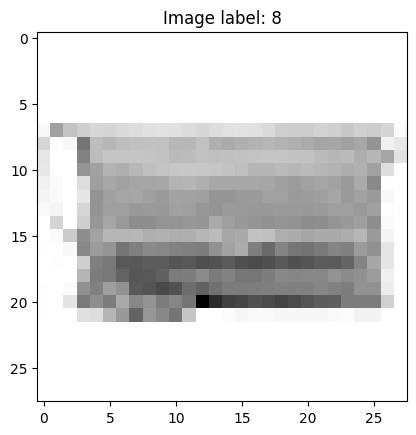

In [8]:
# do not change the code in the block below
# __________start of block__________

train_fmnist_data = FashionMNIST(
    ".", train=True, transform=torchvision.transforms.ToTensor(), download=True
)
test_fmnist_data = FashionMNIST(
    ".", train=False, transform=torchvision.transforms.ToTensor(), download=True
)


train_data_loader = torch.utils.data.DataLoader(
    train_fmnist_data, batch_size=32, shuffle=True, num_workers=2
)

test_data_loader = torch.utils.data.DataLoader(
    test_fmnist_data, batch_size=32, shuffle=False, num_workers=2
)

random_batch = next(iter(train_data_loader))
_image, _label = random_batch[0][0], random_batch[1][0]
plt.figure()
plt.imshow(_image.squeeze(), cmap="Grays")
plt.title(f"Image label: {_label}")
# __________end of block__________

In [9]:
print(_image.device)
print(_image.dtype)
print(_image.shape)
print(_image.squeeze().shape)

cpu
torch.float32
torch.Size([1, 28, 28])
torch.Size([28, 28])


Постройте модель ниже. Пожалуйста, не стройте переусложненную сеть, не стоит делать ее глубже четырех слоев (можно и меньше). Ваша основная задача – обучить модель и получить качество на отложенной (тестовой выборке) не менее 88.5% accuracy.

__Внимание, ваша модель должна быть представлена именно переменной `model_task_1`. На вход ей должен приходить тензор размерностью (1, 28, 28).__

# Анализ датасета

In [17]:
print(f"Train dataset size: {len(train_fmnist_data)}")
print(f"Test dataset size: {len(test_fmnist_data)}")
print(f"Image shape: {train_fmnist_data[0][0].shape}")

Train dataset size: 60000
Test dataset size: 10000
Image shape: torch.Size([1, 28, 28])


In [19]:
from collections import Counter

class_names = train_fmnist_data.classes
train_labels = [label for _, label in train_fmnist_data]
test_labels = [label for _, label in test_fmnist_data]

train_counter = Counter(train_labels)
test_counter = Counter(test_labels)

print("\nClass distribution (train):")
for idx, count in train_counter.items():
    print(f"{class_names[idx]}: {count}")

print("\nClass distribution (test):")
for idx, count in test_counter.items():
    print(f"{class_names[idx]}: {count}")


Class distribution (train):
Ankle boot: 6000
T-shirt/top: 6000
Dress: 6000
Pullover: 6000
Sneaker: 6000
Sandal: 6000
Trouser: 6000
Shirt: 6000
Coat: 6000
Bag: 6000

Class distribution (test):
Ankle boot: 1000
Pullover: 1000
Trouser: 1000
Shirt: 1000
Coat: 1000
Sandal: 1000
Sneaker: 1000
Dress: 1000
Bag: 1000
T-shirt/top: 1000


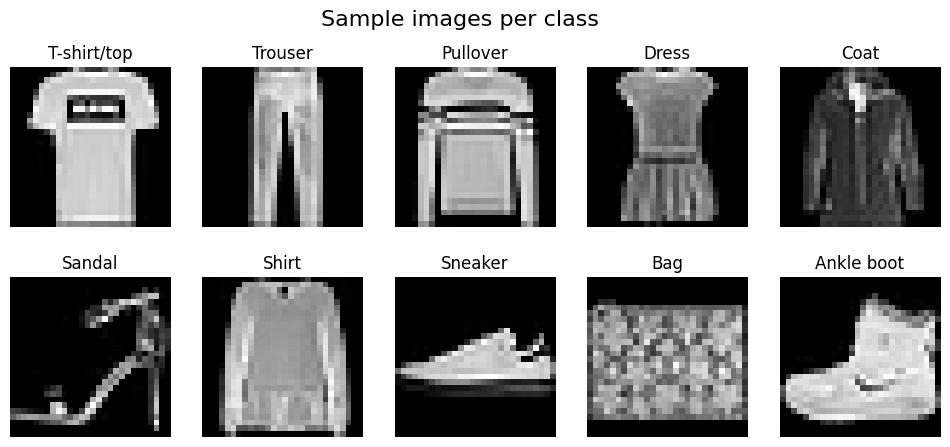

In [20]:
fig, axes = plt.subplots(2,5, figsize=(12,5))
fig.suptitle("Sample images per class", fontsize=16)
for i, ax in enumerate(axes.flatten()):
    idx = train_labels.index(i)
    img, label = train_fmnist_data[idx]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(class_names[label])
    ax.axis('off')
plt.show()

In [23]:
all_train_images = torch.stack([img for img, _ in train_fmnist_data]) # [N,1,28,28]
all_train_pixels = all_train_images.view(-1)
nan_count = torch.isnan(all_train_images).sum().item()
print(f"\nNumber of NaNs in train images: {nan_count}")


Number of NaNs in train images: 0


In [22]:
sample_img, sample_label = train_fmnist_data[0]
assert sample_img.shape == (1,28,28), "Unexpected image shape"
assert 0 <= sample_label < 10, "Label out of range"
print("\nSanity checks passed: image shapes and labels are valid.")


Sanity checks passed: image shapes and labels are valid.


## Выделим validation dataset из train

In [119]:
from torch.utils.data import DataLoader, SubsetRandomSampler

num_train = len(train_fmnist_data)
indices = list(range(num_train))
np.random.shuffle(indices)

split = int(0.2 * num_train)
train_idx, val_idx = indices[split:], indices[:split]

train_sampler = SubsetRandomSampler(train_idx)
val_sampler = SubsetRandomSampler(val_idx)

train_data_loader = DataLoader(
    train_fmnist_data,
    batch_size=32,
    sampler=train_sampler,
    num_workers=2,
    shuffle=False,
    pin_memory=True,
    persistent_workers=False
)

val_data_loader = DataLoader(
    train_fmnist_data,
    batch_size=32,
    sampler=val_sampler,
    num_workers=2,
    shuffle=False,
    pin_memory=True,
    persistent_workers=False
)
print(f"Train batches: {len(train_data_loader)}\nValidation batches: {len(val_data_loader)}\nTest batches: {len(test_data_loader)}")


Train batches: 1500
Validation batches: 375
Test batches: 313


In [32]:
total = len(train_data_loader.sampler.indices) + len(val_data_loader.sampler.indices) + len(test_data_loader.dataset)
print(f"Train: {len(train_data_loader.sampler.indices)/total*100:.1f}%, "
      f"Validation: {len(val_data_loader.sampler.indices)/total*100:.1f}%, "
      f"Test: {len(test_data_loader.dataset)/total*100:.1f}%")


Train: 68.6%, Validation: 17.1%, Test: 14.3%


# Проверка & экспорт модели

In [90]:
def check_model_succeed(model, device, train_data_loader, test_data_loader):
    """
    Проверка модели на random_batch и вычисление accuracy.
    """
    # Создание экземпляра модели
    model_task_1 = model
    print(model_task_1)
    model_task_1.to(device)

    # __________start of block__________
    assert model_task_1 is not None, "Please, use `model_task_1` variable to store your model"

    try:
        x = random_batch[0].to(device)
        y = random_batch[1].to(device)

        # compute outputs given inputs
        y_predicted = model_task_1(x)
    except Exception as e:
        print("Something is wrong with the model")
        raise e

    assert y_predicted.shape[-1] == 10, "Model should predict 10 logits/probas"
    print("Prechecks seems fine!")
    # __________end of block__________

    train_acc_task_1 = get_accuracy(model_task_1, train_data_loader)
    print(f"Neural network accuracy on train set: {train_acc_task_1:3.5}")

    test_acc_task_1 = get_accuracy(model_task_1, test_data_loader)
    print(f"Neural network accuracy on test set: {test_acc_task_1:3.5}")

    assert test_acc_task_1 >= 0.885, "Train accuracy is below 0.885 threshold"
    assert train_acc_task_1 >= 0.905, "Train accuracy is below 0.905 while test accuracy is fine. We recommend to check your model and data flow"

    return model_task_1, train_acc_task_1, test_acc_task_1


def create_submission_task_1(model_task_1):
    """
    Загружает данные из npy, делает предсказания и сохраняет в JSON.
    """
    # __________start of block__________
    assert os.path.exists(
        "hw_fmnist_data_dict.npy"
    ), "Please, download `hw_fmnist_data_dict.npy` and place it in the working directory"

    loaded_data_dict = np.load("hw_fmnist_data_dict.npy", allow_pickle=True)

    submission_dict = {
        "train_predictions_task_1": get_predictions(
            model_task_1, torch.FloatTensor(loaded_data_dict.item()["train"])
        ),
        "test_predictions_task_1": get_predictions(
            model_task_1, torch.FloatTensor(loaded_data_dict.item()["test"])
        ),
    }

    with open("submission_dict_fmnist_task_1.json", "w") as iofile:
        json.dump(submission_dict, iofile)
    print("File saved to `submission_dict_fmnist_task_1.json`")
    # __________end of block__________

    return submission_dict


# Архитектуры

## MLP (sanity check)

Flatten → { [FC → ReLU] × N раз } → FC_out → Softmax

In [10]:
device

device(type='cuda', index=0)

In [41]:
import torch
from torch import nn

class MLP_FashionMNIST(nn.Module):
    def __init__(self, input_dim=28*28, hidden_dim=128, num_classes=10, num_hidden_layers=1):
        super().__init__()
        self.flatten = nn.Flatten()
        self.hidden_layers = nn.ModuleList()
        self.hidden_layers.append(nn.Linear(input_dim, hidden_dim))
        for _ in range(num_hidden_layers - 1):
            self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.relu = nn.ReLU()
        self.fc_out = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        if x.dim() != 3 and x.dim() != 4:
            raise ValueError(f"Expected input with 3 or 4 dims, got {x.shape}")

        if x.dim() == 3:  # если одиночный пример [1,28,28], добавляем batch
            x = x.unsqueeze(0)

        x = self.flatten(x)
        for layer in self.hidden_layers:
            x = self.relu(layer(x))
        logits = self.fc_out(x)
        return logits


In [42]:
from dataclasses import dataclass

@dataclass
class MLP_Config:
    input_dim: int = 28*28
    hidden_dim: int = 128
    num_hidden_layers: int = 2
    num_classes: int = 10
    dropout: float = 0.2
    learning_rate: float = 1e-3
    optimizer: str = "Adam"
    trial_epochs: int = 2
    search_space: dict = None

In [49]:
%pip install optuna tqdm rich

In [76]:
import torch.optim as optim
from dataclasses import dataclass, asdict
import optuna
from tqdm import tqdm
from rich.table import Table
from rich.console import Console
import copy

console = Console()

def _train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for X, y in tqdm(loader, desc="Training", leave=False):
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)
    return running_loss / len(loader.dataset)

def _evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            preds = model(X).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total

def _objective(trial, model_class, config_dataclass, train_loader, val_loader, device):
    """Objective for Optuna adaptive search."""
    config_dict = asdict(config_dataclass)

    # Пробуем варианты гиперпараметров
    for param, values in config_dict.get("search_space", {}).items():
        if isinstance(values, list):
            config_dict[param] = trial.suggest_categorical(param, values)
        elif isinstance(values, tuple) and len(values) == 2:
            config_dict[param] = trial.suggest_float(param, values[0], values[1], log=True)

    # Создаём модель
    model = model_class(**{k: v for k, v in config_dict.items() if k in model_class.__init__.__code__.co_varnames})
    model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer_name = config_dict.get("optimizer", "Adam")
    lr = config_dict.get("learning_rate", 1e-3)
    optimizer = getattr(optim, optimizer_name)(model.parameters(), lr=lr)

    # Быстро обучаем 1–2 эпохи
    for epoch in range(config_dict.get("trial_epochs", 2)):
        _train_one_epoch(model, train_loader, criterion, optimizer, device)

    val_acc = _evaluate(model, val_loader, device)

    # Логируем параметры и accuracy для прогресса
    trial.set_user_attr("params", config_dict)
    trial.set_user_attr("val_acc", val_acc)
    trial.set_user_attr("model_state", copy.deepcopy(model.state_dict()))

    return val_acc

def adaptive_hyperparam_search(model_class, config_dataclass, train_loader, val_loader, device, n_trials=10):
    """
    Returns:
        tuple:
            best_params (dict): Dictionary of best hyperparameters found by Optuna.
            all_results (list[dict]): List of dictionaries containing trial results.
                Each entry has the following keys:
                    - "trial_number" (int): Trial index.
                    - "val_acc" (float): Validation accuracy for this trial.
                    - "params" (dict): Hyperparameters used in this trial.
    """

    study = optuna.create_study(direction="maximize")
    all_results = []  # список для экспорта

    for _ in tqdm(range(n_trials), desc="Optuna trials"):
        study.optimize(lambda trial: _objective(trial, model_class, config_dataclass, train_loader, val_loader, device),
                       n_trials=1, catch=(Exception,))

        # сохраняем последний trial
        t = study.trials[-1]
        all_results.append({
            "trial_number": t.number,
            "val_acc": t.value,
            "params": t.params
        })

    # Выводим красивую таблицу через rich
    table = Table(title="Hyperparameter Search Results")
    table.add_column("Trial #", style="cyan", justify="right")
    table.add_column("Val Accuracy", style="green", justify="right")
    table.add_column("Params", style="magenta")

    for r in all_results:
        table.add_row(str(r["trial_number"]), f"{r['val_acc']:.4f}", str(r["params"]))

    console.print(table)

    print("\nBest trial:")
    print(study.best_trial.params)
    print("Best validation accuracy:", study.best_trial.value)

    best_params = study.best_trial.params
    best_model_state = study.best_trial.user_attrs["model_state"]

    return best_params, best_model_state

In [78]:
_mlp_config = MLP_Config(
    search_space={
        "hidden_dim": [64, 128, 256],
        "num_hidden_layers": [1, 2, 3],
        "learning_rate": (1e-4, 1e-2),
        "optimizer": ["Adam", "SGD"]
    }
)

_mlp_best_params, _mlp_model_state = adaptive_hyperparam_search(model_class=MLP_FashionMNIST,
                                                      config_dataclass=_mlp_config,
                                                      train_loader=train_data_loader,
                                                      val_loader=val_data_loader,
                                                      device=device,
                                                      n_trials=3)

[I 2025-09-14 13:52:40,164] A new study created in memory with name: no-name-dfde76e5-ab37-4f27-adb2-a0521efa4cd4
Training: 100%|█████████▉| 1496/1500 [00:09<00:00, 183.80it/s]
                                                              
Training:  99%|█████████▉| 1483/1500 [00:09<00:00, 174.75it/s]
                                                              [I 2025-09-14 13:53:00,437] Trial 0 finished with value: 0.8660833333333333 and parameters: {'hidden_dim': 256, 'num_hidden_layers': 1, 'learning_rate': 0.002158773656633443, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.8660833333333333.
Training: 100%|█████████▉| 1497/1500 [00:09<00:00, 110.11it/s]
                                                              
Training:  99%|█████████▉| 1489/1500 [00:09<00:00, 106.39it/s]
                                                              [I 2025-09-14 13:53:22,362] Trial 1 finished with value: 0.7721666666666667 and parameters: {'hidden_dim': 64, 'num_hidden_layers': 3, 'lea

                                           Hyperparameter Search Results                                           
┏━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial # ┃ Val Accuracy ┃ Params                                                                                 ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       0 │       0.8661 │ {'hidden_dim': 256, 'num_hidden_layers': 1, 'learning_rate': 0.002158773656633443,     │
│         │              │ 'optimizer': 'Adam'}                                                                   │
│       1 │       0.7722 │ {'hidden_dim': 64, 'num_hidden_layers': 3, 'learning_rate': 0.00900479416392185,       │
│         │              │ 'optimizer': 'SGD'}                                                                    │
│       2 │       0.8673 │ {'hidden_dim': 128, 'num_hidden_layers': 2, 'learning_rate': 0.0005080912098741867,    │
│         │              │ 'optimizer': 'Adam'}                                                                   │
└─────────┴──────────────┴────────────────────────────────────────────────────────────────────────────────────────┘


Best trial:
{'hidden_dim': 128, 'num_hidden_layers': 2, 'learning_rate': 0.0005080912098741867, 'optimizer': 'Adam'}
Best validation accuracy: 0.8673333333333333


In [79]:
_mlp_model_args = {k: v for k, v in _mlp_best_params.items()
                   if k in MLP_FashionMNIST.__init__.__code__.co_varnames}
mlp_model = MLP_FashionMNIST(**_mlp_model_args)

mlp_model.load_state_dict(_mlp_model_state)

_mlp_optimizer_name = _mlp_best_params.get("optimizer", "Adam")
_mlp_lr = _mlp_best_params.get("learning_rate", 1e-3)
mlp_optimizer = getattr(torch.optim, _mlp_optimizer_name)(mlp_model.parameters(), lr=_mlp_lr)

print("Best params:", _mlp_best_params)
print(mlp_model)
print(mlp_optimizer)


Best params: {'hidden_dim': 128, 'num_hidden_layers': 2, 'learning_rate': 0.0005080912098741867, 'optimizer': 'Adam'}
MLP_FashionMNIST(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden_layers): ModuleList(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=128, bias=True)
  )
  (relu): ReLU()
  (fc_out): Linear(in_features=128, out_features=10, bias=True)
)
Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0005080912098741867
    maximize: False
    weight_decay: 0
)


## ResNetMini

In [43]:
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride,
                               padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1,
                               padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Прямое соединение, если меняем размерность
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


In [44]:
class ResNetMini(nn.Module):
    def __init__(self, block=ResidualBlock, num_blocks=[2,2], num_classes=10):
        super().__init__()
        self.in_channels = 16
        # input: (1, 28, 28)
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)

        # residual blocks
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)

        # global average pooling + FC
        self.avg_pool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(32, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, stride=s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(0)  # (1, 28, 28) -> (1, 1, 28, 28)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.avg_pool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

In [45]:
@dataclass
class ResNetMini_Config:
    block: type = ResidualBlock
    num_blocks: list = None        # [layer1_blocks, layer2_blocks]
    learning_rate: float = 1e-3
    optimizer: str = "Adam"
    trial_epochs: int = 2
    search_space: dict = None

In [46]:
_resnet_config = ResNetMini_Config(
    search_space={
        "num_blocks": [[3,3], [3,4]],
        "learning_rate": (1e-4, 1e-2),
        "optimizer": ["Adam", "AdamW"]
    },
    trial_epochs=3
)

In [110]:
_resnet_best_params, _resnet_model_state = adaptive_hyperparam_search(model_class=ResNetMini,
                                                      config_dataclass=_resnet_config,
                                                      train_loader=train_data_loader,
                                                      val_loader=val_data_loader,
                                                      device=device,
                                                      n_trials=5)

[I 2025-09-14 14:24:14,297] A new study created in memory with name: no-name-3c7d5606-a42b-474d-8887-ab67e8fa9ecc
Optuna trials:   0%|          | 0/3 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [3, 3] which is of type list.
  warnings.warn(message)
/usr/local/lib/python3.12/dist-packages/optuna/distributions.py:518: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains [3, 4] which is of type list.
  warnings.warn(message)

Training:  99%|█████████▉| 1491/1500 [00:19<00:00, 81.39it/s]
                                                             
Training: 100%|█████████▉| 1498/1500 [00:19<00:00, 83.14it/s]
                                                             
Training: 100%|█████████▉| 1498/1500 [00:20<00:00, 84.09i

                                          Hyperparameter Search Results                                          
┏━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Trial # ┃ Val Accuracy ┃ Params                                                                               ┃
┡━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       0 │       0.9013 │ {'num_blocks': [3, 3], 'learning_rate': 0.0003632723882862119, 'optimizer': 'AdamW'} │
│       1 │       0.9104 │ {'num_blocks': [3, 4], 'learning_rate': 0.004453373982647165, 'optimizer': 'AdamW'}  │
│       2 │       0.9130 │ {'num_blocks': [3, 4], 'learning_rate': 0.006485613279997598, 'optimizer': 'Adam'}   │
└─────────┴──────────────┴──────────────────────────────────────────────────────────────────────────────────────┘


Best trial:
{'num_blocks': [3, 4], 'learning_rate': 0.006485613279997598, 'optimizer': 'Adam'}
Best validation accuracy: 0.913


In [114]:
_resnet_model_args = {k: v for k, v in _resnet_best_params.items()
                      if k in ResNetMini.__init__.__code__.co_varnames}

resnet_model = ResNetMini(**_resnet_model_args).to(device)
resnet_model.load_state_dict(_resnet_model_state)


_resnet_optimizer_name = _resnet_best_params["optimizer"]
_resnet_lr = _resnet_best_params["learning_rate"]
resnet_optimizer = getattr(torch.optim, _resnet_optimizer_name)(
    resnet_model.parameters(),
    lr=_resnet_lr
)

### Дообучим

In [120]:
from tqdm import trange

criterion = nn.CrossEntropyLoss()

num_extra_epochs = 4
patience = 2
best_val_acc = 0.0
epochs_no_improve = 0

for epoch in trange(num_extra_epochs, desc="Extra training epochs"):
    train_loss = _train_one_epoch(resnet_model, train_data_loader, criterion, resnet_optimizer, device)
    train_acc = _evaluate(resnet_model, train_data_loader, device)
    val_acc = _evaluate(resnet_model, val_data_loader, device)

    trange_desc = (f"Epoch {epoch+1}/{num_extra_epochs} | "
                   f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    tqdm.write(trange_desc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_no_improve = 0
        best_model_state = copy.deepcopy(resnet_model.state_dict())
        tqdm.write(f"🎯 New best model found! Val Acc: {best_val_acc:.4f}")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            tqdm.write(f"⏹ Early stopping triggered at epoch {epoch+1}")
            break

resnet_model.load_state_dict(best_model_state)


Extra training epochs:  25%|██▌       | 1/4 [00:34<01:43, 34.65s/it]

Epoch 1/4 | Train Loss: 0.1727 | Train Acc: 0.9342 | Val Acc: 0.9261
🎯 New best model found! Val Acc: 0.9261



Extra training epochs:  50%|█████     | 2/4 [01:13<01:13, 36.96s/it]

Epoch 2/4 | Train Loss: 0.1622 | Train Acc: 0.9265 | Val Acc: 0.9177



Extra training epochs:  50%|█████     | 2/4 [01:48<01:48, 54.40s/it]

Epoch 3/4 | Train Loss: 0.1503 | Train Acc: 0.9392 | Val Acc: 0.9245
⏹ Early stopping triggered at epoch 3


<All keys matched successfully>

# Моя проверка модели

In [122]:
# Creating model instance
model_task_1 = None

mlp_model
resnet_model

check_model_succeed_args = {"device": device, "train_data_loader": train_data_loader, "test_data_loader": test_data_loader}
check_model_succeed(model=resnet_model, **check_model_succeed_args)


ResNetMini(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.

(ResNetMini(
   (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
   (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (layer1): Sequential(
     (0): ResidualBlock(
       (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (shortcut): Sequential()
     )
     (1): ResidualBlock(
       (conv1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       (conv2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       (bn2): BatchNorm2d(16, eps=1e

Не забудьте перенести модель на выбранный `device`!

## Сдача задания

In [ ]:
torch.save(resnet_model.state_dict(), "resnet_model_weights.pth")
torch.save(_resnet_model_args, "resnet_model_params.pth")

print("✅ Модель сохранена")

NameError: name 'resnet_model' is not defined

In [49]:
model_args = torch.load("resnet_model_params.pth")

resnet_model_loaded = ResNetMini(**model_args).to(device)
resnet_model_loaded.load_state_dict(torch.load("resnet_model_weights.pth", map_location=device))
resnet_model_loaded.eval()
print("✅ Модель загружена и готова к использованию")


✅ Модель загружена и готова к использованию


In [51]:
submission_json = create_submission_task_1(model_task_1=resnet_model_loaded)
submission_json

File saved to `submission_dict_fmnist_task_1.json`


{'train_predictions_task_1': '1,4,8,1,7,9,5,6,8,1,7,6,7,2,4,9,8,0,2,2,6,4,1,4,4,3,2,4,4,2,1,5,0,8,7,9,2,4,9,1,0,9,2,5,9,3,9,1,5,7,2,8,1,5,8,0,7,2,8,6,3,7,0,3,0,6,1,3,2,7,1,6,3,0,3,3,5,1,9,9,2,0,1,7,7,4,2,7,5,9,0,2,1,9,7,7,1,0,0,0,0,5,3,7,7,7,8,6,0,6,1,4,2,3,5,9,1,6,3,0,1,1,9,1,6,0,5,6,4,4,8,7,0,5,0,3,5,6,5,2,2,1,8,1,3,2,0,9,0,5,8,8,6,7,1,0,1,3,6,2,7,4,7,9,0,6,0,2,9,7,5,7,7,3,4,9,9,4,8,1,2,9,8,8,7,2,8,3,3,3,4,6,9,8,0,5,6,7,9,7,2,3,4,4,5,6,7,5,4,9,3,4,7,9,9,7,4,4,9,2,6,5,8,7,0,4,9,8,4,8,2,1,7,4,6,8,2,7,9,3,8,9,7,8,7,0,7,5,0,2,0,2,2,5,2,7,1,0,6,1,9,7,7,8,1,1,8,7,3,2,5,3,1,7,4,9,2,3,2,5,1,4,6,4,9,7,5,5,9,3,7,4,6,3,4,5,2,8,3,0,9,5,0,8,1,8,0,1,6,4,6,7,5,1,2,3,8,4,4,9,5,6,1,8,3,9,3,8,9,8,7,8,0,4,9,9,2,8,7,3,4,0,3,7,7,7,1,0,0,2,6,8,3,6,6,7,8,5,1,3,4,1,5,6,7,9,6,4,4,2,9,0,4,5,5,5,5,0,7,3,1,4,9,0,0,2,6,5,4,0,5,3,6,9,6,2,2,7,9,9,3,0,6,7,2,2,4,4,2,3,7,4,8,8,6,4,9,5,3,1,0,8,6,5,1,7,1,4,4,0,6,6,7,9,7,3,3,0,8,8,6,5,5,6,8,2,8,4,5,5,4,0,0,2,4,2,5,5,4,0,5,5,0,0,7,9,7,6,8,6,8,4,5,6,9,3,7,8,6,6,4,5,3,6,2,

# Старая проверка модели

In [81]:
model_task_1.to(device)

MLP_FashionMNIST(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (hidden_layers): ModuleList(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): Linear(in_features=128, out_features=128, bias=True)
  )
  (relu): ReLU()
  (fc_out): Linear(in_features=128, out_features=10, bias=True)
)

Локальные тесты для проверки вашей модели доступны ниже:

In [82]:
# do not change the code in the block below
# __________start of block__________
assert model_task_1 is not None, "Please, use `model_task_1` variable to store your model"

try:
    x = random_batch[0].to(device)
    y = random_batch[1].to(device)

    # compute outputs given inputs, both are variables
    y_predicted = model_task_1(x)
except Exception as e:
    print("Something is wrong with the model")
    raise e


assert y_predicted.shape[-1] == 10, "Model should predict 10 logits/probas"

print("Everything seems fine!")
# __________end of block__________

Everything seems fine!


Настройте параметры модели на обучающей выборке. Также рекомендуем поработать с `learning rate`.

In [83]:
# your code here

Также, напоминаем, что в любой момент можно обратиться к замечательной [документации](https://pytorch.org/docs/stable/index.html) и [обучающим примерам](https://pytorch.org/tutorials/).  

Оценим качество классификации:

In [84]:
train_acc_task_1 = get_accuracy(model_task_1, train_data_loader)
print(f"Neural network accuracy on train set: {train_acc_task_1:3.5}")

Neural network accuracy on train set: 0.87081


In [85]:
test_acc_task_1 = get_accuracy(model_task_1, test_data_loader)
print(f"Neural network accuracy on test set: {test_acc_task_1:3.5}")

Neural network accuracy on test set: 0.857


Проверка, что необходимые пороги пройдены:

In [86]:
assert test_acc_task_1 >= 0.885, "Train accuracy is below 0.885 threshold"
assert (
    train_acc_task_1 >= 0.905
), "Train accuracy is below 0.905 while test accuracy is fine. We recommend to check your model and data flow"

AssertionError: Train accuracy is below 0.885 threshold

Обращаем внимане, код ниже предполагает, что ваша модель имеет содержится в переменной `model_task_1`, а файл `hw_fmnist_data_dict.npy` находится в той же директории, что и ноутбук (он доступен в репозитории).

In [124]:
# do not change the code in the block below
# __________start of block__________
assert os.path.exists(
    "hw_fmnist_data_dict.npy"
), "Please, download `hw_fmnist_data_dict.npy` and place it in the working directory"

loaded_data_dict = np.load("hw_fmnist_data_dict.npy", allow_pickle=True)

submission_dict = {
    "train_predictions_task_1": get_predictions(
        model_task_1, torch.FloatTensor(loaded_data_dict.item()["train"])
    ),
    "test_predictions_task_1": get_predictions(
        model_task_1, torch.FloatTensor(loaded_data_dict.item()["test"])
    ),
}

with open("submission_dict_fmnist_task_1.json", "w") as iofile:
    json.dump(submission_dict, iofile)
print("File saved to `submission_dict_fmnist_task_1.json`")
# __________end of block__________

AssertionError: Please, download `hw_fmnist_data_dict.npy` and place it in the working directory

### Сдача задания
Сдайте сгенерированный файл в соответствующую задачу в соревновании, а именно:
    
* `submission_dict_fmnist_task_1.json` в задачу Separation

На этом задание завершено. Поздравляем!